In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
from notebooks.consts import OLIGO_CSV_INDEXED
import pandas as pd

data = pd.read_csv(OLIGO_CSV_INDEXED)

In [23]:
# Filter where target_gene is PSD3 AND custom_id matches the string
filtered_data = data[(data['target_gene'] == 'PSD3') &
                     (data['custom_id'] == 'patent-scrape-v2/data/inhibition_tables/US20230167446A1_table_00002.xml')]

print(len(filtered_data))

2234


In [41]:
filtered_data['split']

156756    test
156757    test
156758    test
156759    test
156760    test
          ... 
158985    test
158986    test
158987    test
158988    test
158989    test
Name: split, Length: 2234, dtype: object

In [3]:
from notebooks.preprocessing import process_oligo_data_rename

data = process_oligo_data_rename(data)

In [4]:
# Unfortunately we must calculate this feature here to properly discard data.
# Must be done with the same API in the feature calculation notebook
from tauso.populate.calculators.calculator import Calculator

calculator = Calculator(data=data, data_version='oligo', overwrite=True, cpus=32)
calculator.calculate_structure()

Computing structure features...
Loading genome data dictionary into memory (happens once)...
[Task] finished in 0.0005s
Elapsed DB:  0.00048089027404785156
Elapsed Fasta:  0.00048089027404785156
Length:  3267117988
Saved feature: sense_start
File exists for 'sense_start_from_end' but values are identical (within tolerance). No action taken.
File exists for 'sense_length' but values are identical (within tolerance). No action taken.
File exists for 'sense_exon' but values are identical (within tolerance). No action taken.
File exists for 'sense_intron' but values are identical (within tolerance). No action taken.
File exists for 'sense_utr' but values are identical (within tolerance). No action taken.
File exists for 'sense_type' but values are identical (within tolerance). No action taken.


In [6]:
data = calculator.data

In [7]:
from notebooks.preprocessing import process_oligo_data

# 785 with multiple target genes present were already eliminated previously
processed_data = process_oligo_data(data, strict_gapmer_patterns=True)

------------------------------------------------------------
PROCESSING FILTERING REPORT
------------------------------------------------------------
Initial raw rows loaded: 173,191

[0. BASE FILTERING]
Unsupported chemistry (Mixmers/DNA/None): 21,012
Steric blocking (True) eliminated: 0
Multiple genes (';' present) eliminated: 0
Missing inhibition (NaN) eliminated: 0
Missing cell line (NaN) eliminated: 5,151

[1. UNMAPPED SEQUENCES (sense_start == -1)]
Samples eliminated: 7,476

[2. STRICT GAPMER PATTERNS (5-10-5 MOE / 3-10-3 cEt)]
Non standard sequences eliminated: 8,225

[3. COHORT FILTERING (>= 1 samples)]
Cohorts: 270 -> 270 (0 eliminated)
Samples: 131,327 -> 131,327 (0 eliminated)

[4. SPARSE CELL LINE FILTERING (>= 1 samples)]
Cell Lines: 35 -> 35 (0 eliminated)
Samples: 131,327 -> 131,327 (0 eliminated)

FINAL DATASET: 131,327 ASOs

ELIMINATED GROUPS BREAKDOWN

[ELIMINATED UNMAPPED SAMPLES] - 7,476 samples across 233 genes:
  • DMPK: 653 samples
  • DUX4: 629 samples
  • KCNQ2

In [8]:
from notebooks.consts import OLIGO_CSV_PROCESSED

processed_data.to_csv(OLIGO_CSV_PROCESSED)

In [9]:
from tauso.data.consts import INHIBITION
from notebooks.consts import OLIGO_CSV_PROCESSED_AVERAGED # or wherever you want to save the output

# 2. Dynamically grab all feature columns (excluding the target and the index)
# This prevents you from having to hardcode hundreds of sequence features.
feature_cols = [col for col in processed_data.columns if col not in [INHIBITION, 'index_oligo']]

# 3. Group by the exact matching features, average the inhibition, and grab the first index
averaged_df = processed_data.groupby(feature_cols, as_index=False, dropna=False).agg({
    INHIBITION: 'mean',
    'index_oligo': 'first'
})

# 4. Reorder the dataframe the index is back at the front
final_cols = ['index_oligo'] + feature_cols + [INHIBITION]
averaged_df = averaged_df[final_cols]

# 5. Save the averaged dataset
averaged_df.to_csv(OLIGO_CSV_PROCESSED_AVERAGED, index=False)
print(f"Collapsed data from {len(processed_data)} rows down to {len(averaged_df)} rows.")

Collapsed data from 131327 rows down to 130959 rows.


/tmp/ipykernel_4121162/1746264661.py:33: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


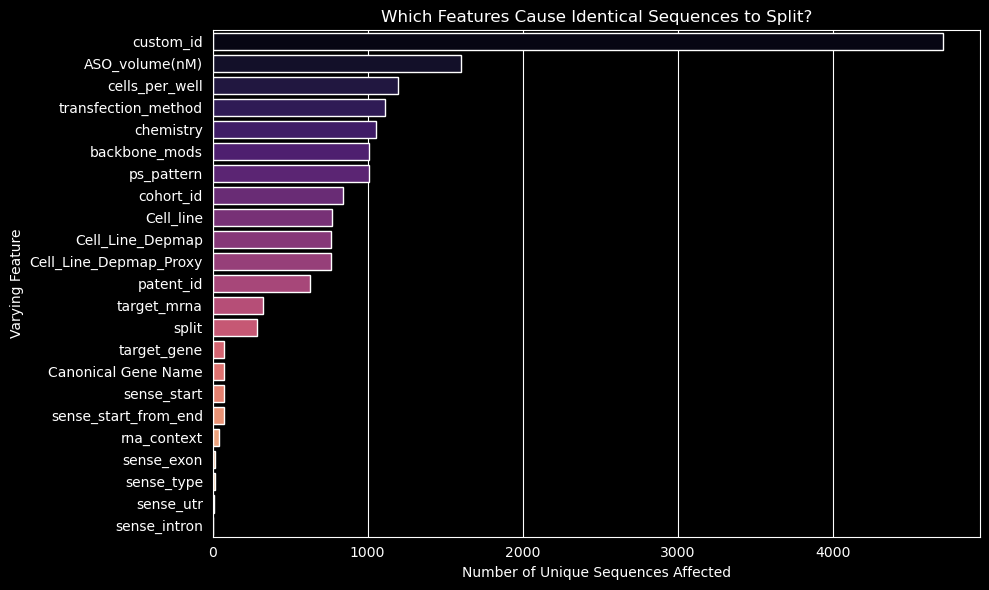

                   Feature  Number of Sequences Split
0                custom_id                       4715
2           ASO_volume(nM)                       1602
7           cells_per_well                       1194
8      transfection_method                       1114
1                chemistry                       1055
3            backbone_mods                       1006
5               ps_pattern                       1006
9                cohort_id                        838
6                Cell_line                        768
11        Cell_Line_Depmap                        764
10  Cell_Line_Depmap_Proxy                        764
4                patent_id                        626
12             target_mrna                        326
13                   split                        288
14             target_gene                         70
15     Canonical Gene Name                         70
16             sense_start                         70
17    sense_start_from_end  

In [10]:
from collections import defaultdict
from tauso.data.consts import SEQUENCE
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Isolate rows where the SEQUENCE appears more than once in averaged_df
duplicates_only = averaged_df[averaged_df.duplicated(subset=[SEQUENCE], keep=False)]

# 2. Dictionary to track how many unique sequences are split by each column
variation_counts = defaultdict(int)

# 3. Group by SEQUENCE and check which columns differ within each group
grouped_seqs = duplicates_only.groupby(SEQUENCE)

for seq, group in grouped_seqs:
    for col in group.columns:
        # Skip the sequence itself, the target, and the unique index
        if col in [SEQUENCE, INHIBITION, 'index_oligo']:
            continue

        # If this column has more than 1 unique value for this sequence, it caused a split
        if group[col].nunique(dropna=False) > 1:
            variation_counts[col] += 1

# 4. Convert the counts into a DataFrame for plotting
variation_df = pd.DataFrame(
    list(variation_counts.items()),
    columns=['Feature', 'Number of Sequences Split']
).sort_values(by='Number of Sequences Split', ascending=False)

# 5. Plot the results
plt.figure(figsize=(10, 6))
sns.barplot(
    data=variation_df,
    x='Number of Sequences Split',
    y='Feature',
    palette='magma'
)

plt.title("Which Features Cause Identical Sequences to Split?")
plt.xlabel("Number of Unique Sequences Affected")
plt.ylabel("Varying Feature")
plt.tight_layout()
plt.savefig("sequence_variation_plot.png") # Saves the plot to your directory
plt.show()

# Print the text summary as well
print(variation_df)

In [11]:
import pandas as pd

# 1. Isolate rows where BOTH SEQUENCE and custom_id are identical
subset_cols = [SEQUENCE, 'custom_id']
duplicates_only = averaged_df[averaged_df.duplicated(subset=subset_cols, keep=False)]

# 2. Find which columns vary within these specific groups
varying_columns = set()
grouped = duplicates_only.groupby(subset_cols)

for _, group in grouped:
    for col in group.columns:
        # Skip our grouping keys and our known variables
        if col in subset_cols + [INHIBITION, 'index_oligo']:
            continue

        # If there's more than 1 unique value, it's causing a split
        if group[col].nunique(dropna=False) > 1:
            varying_columns.add(col)

print("When both SEQUENCE and custom_id are identical, these columns differ:")
for col in sorted(varying_columns):
    print(f" - {col}")

# Optional: Peek at the actual varying values for the first group to see what's happening
if not duplicates_only.empty:
    first_group = list(grouped)[0][1]
    print("\nExample of differing values for the first duplicated pair:")
    for col in varying_columns:
        print(f" {col}: {first_group[col].unique()}")

When both SEQUENCE and custom_id are identical, these columns differ:
 - backbone_mods
 - chemistry
 - ps_pattern

Example of differing values for the first duplicated pair:
 backbone_mods: ["['PS', 'PS', 'PS', 'PS', 'PS', 'PS', 'PS', 'PS', 'PS', 'PS', 'PS', 'PS', 'PS', 'PS', 'PS', 'PS', 'PS', 'PS', 'PS', '<PAD>']"
 "['PS', 'PO', 'PO', 'PO', 'PS', 'PS', 'PS', 'PS', 'PS', 'PS', 'PS', 'PS', 'PS', 'PS', 'PS', 'PO', 'PO', 'PS', 'PS', '<PAD>']"]
 chemistry: ["length=20 modifications=[Modification(modification='MOE', type='sugar', positions=[1, 2, 3, 4, 5, 16, 17, 18, 19, 20]), Modification(modification='PS', type='backbone', positions=[1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19])]"
 "length=20 modifications=[Modification(modification='MOE', type='sugar', positions=[1, 2, 3, 4, 5, 16, 17, 18, 19, 20]), Modification(modification='PS', type='backbone', positions=[1, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 18, 19])]"]
 ps_pattern: ['*******************' '*ddd***********dd*

In [12]:
import pandas as pd
from collections import defaultdict

# 1. Isolate rows where BOTH SEQUENCE and custom_id are identical
subset_cols = [SEQUENCE, 'custom_id']
duplicates_only = averaged_df[averaged_df.duplicated(subset=subset_cols, keep=False)]

# 2. Dictionary to count how many unique (Sequence + ID) pairs are split by each feature
variation_counts = defaultdict(int)

# 3. Group by SEQUENCE and custom_id
grouped = duplicates_only.groupby(subset_cols)
total_duplicated_groups = len(grouped)

for _, group in grouped:
    for col in group.columns:
        if col in subset_cols + [INHIBITION, 'index_oligo']:
            continue

        # If there's more than 1 unique value, it caused a split for this specific sequence pair
        if group[col].nunique(dropna=False) > 1:
            variation_counts[col] += 1

# 4. Format and print the results
print(f"Total number of identical (SEQUENCE + custom_id) pairs found: {total_duplicated_groups}\n")
print("Number of times each feature caused these pairs to split into different rows:")
print("-" * 65)

# Sort by the highest counts
for col, count in sorted(variation_counts.items(), key=lambda item: item[1], reverse=True):
    percentage = (count / total_duplicated_groups) * 100
    print(f"{col:<25} | Split {count} pairs ({percentage:.1f}%)")

Total number of identical (SEQUENCE + custom_id) pairs found: 12

Number of times each feature caused these pairs to split into different rows:
-----------------------------------------------------------------
chemistry                 | Split 12 pairs (100.0%)
backbone_mods             | Split 12 pairs (100.0%)
ps_pattern                | Split 12 pairs (100.0%)


In [17]:
processed_data['Cell_line'].unique()

array(['SH-SY5Y', 'A431', 'THP-1', 'Hep3B', 'hSKMc', 'LNCaP', 'T24',
       'MM.1R', 'SK-MEL-28', 'iCell GABANeurons', 'HepG2', 'A549', 'VCaP',
       'Huh7', 'HepaRG', 'U251', 'Jurkat', 'SCA2-04',
       'iCell cardiomyocytes2', '54-2', 'HUVEC', 'SKOV3', 'K-562', 'HeLa',
       'SNU-449', 'ReproNeuro Neurons (ReproCELL)',
       'differentiated human adipocytes', 'ReproNeuro Neurons', 'PC3',
       'MCF7', 'SW872', 'HK-2', 'ReproNeuro neurons (ReproCELL)', 'G-361',
       'ReproNeuro'], dtype=object)